<a href="https://colab.research.google.com/github/AYCDJ/Monkeytype-Data/blob/main/ProcessingTideData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hi
processing  BHP9317data.csv
removing missing values


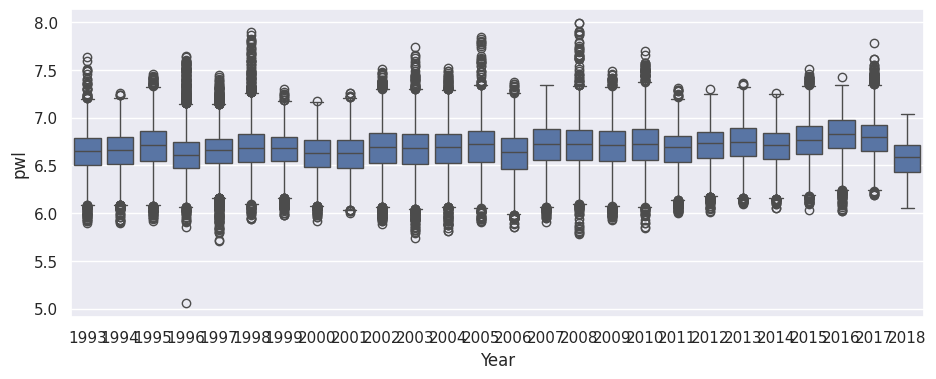

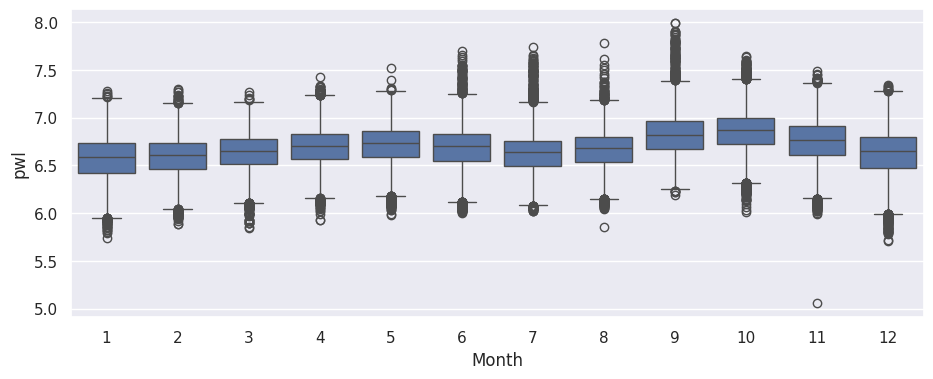

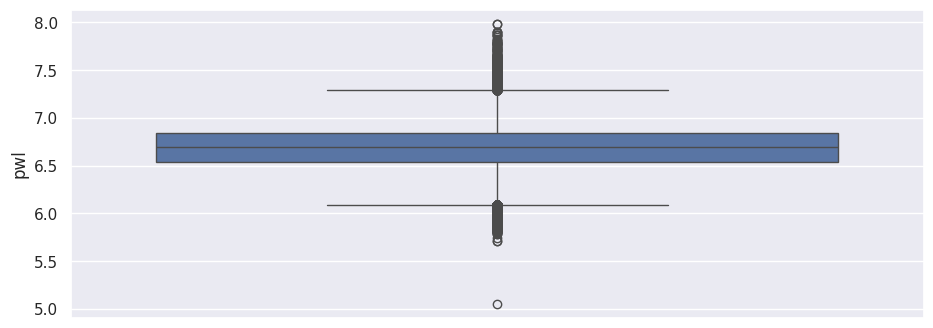

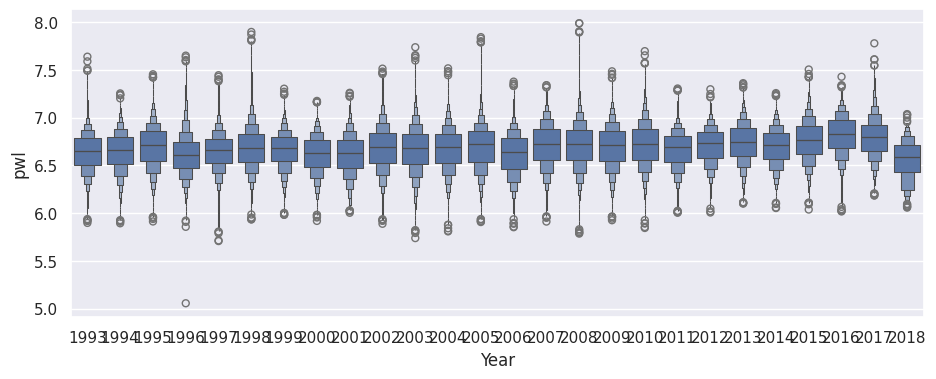

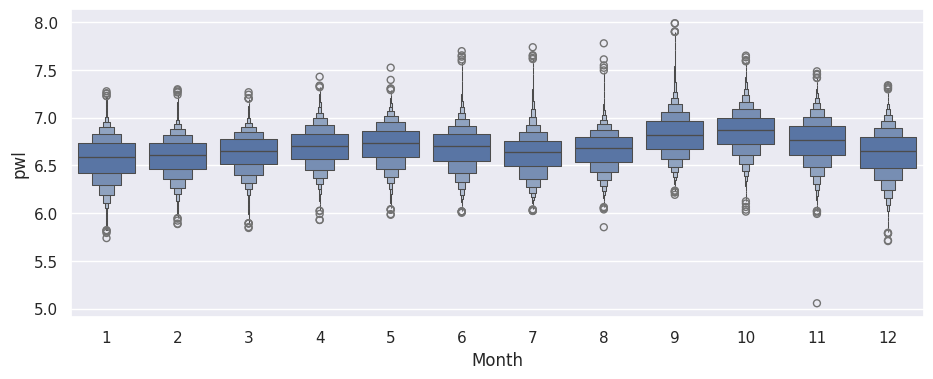

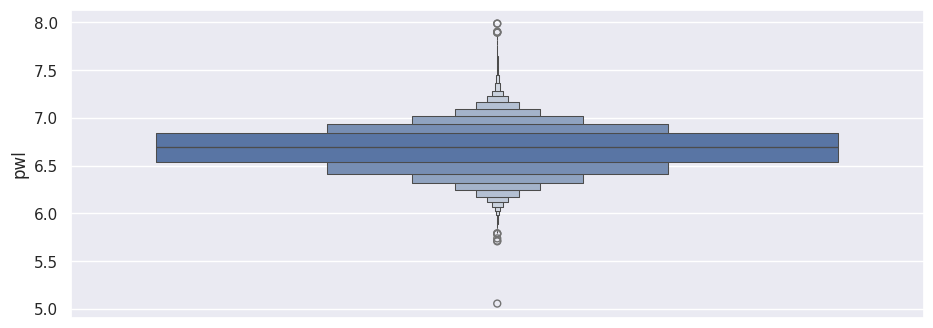

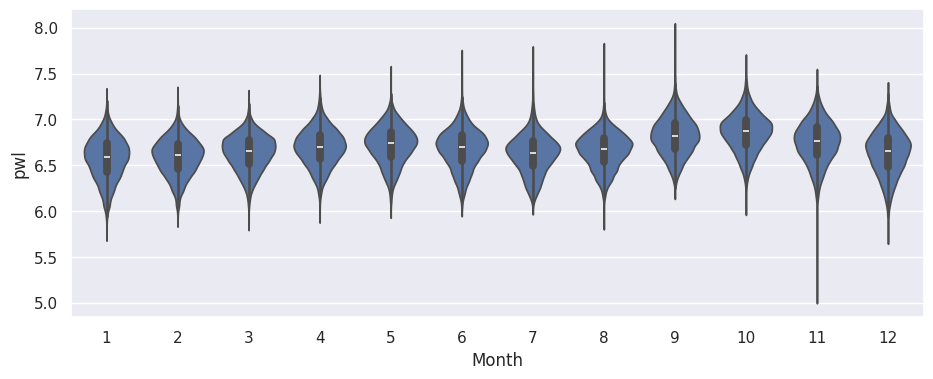

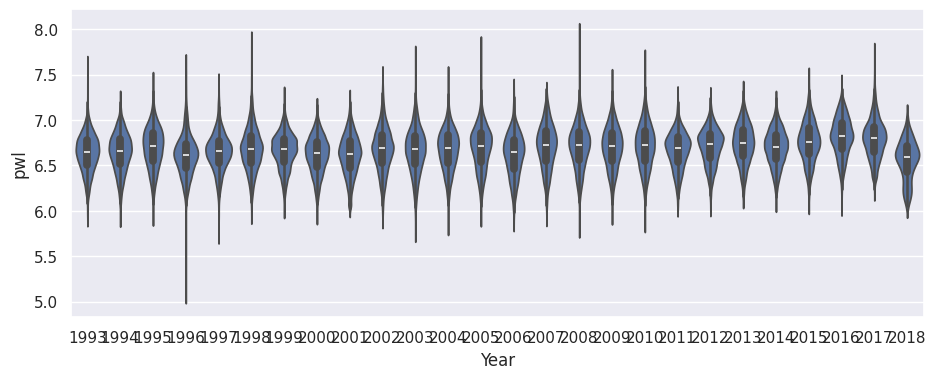

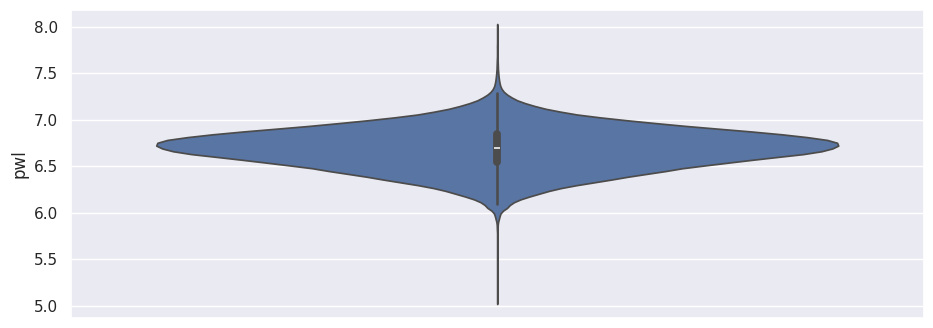

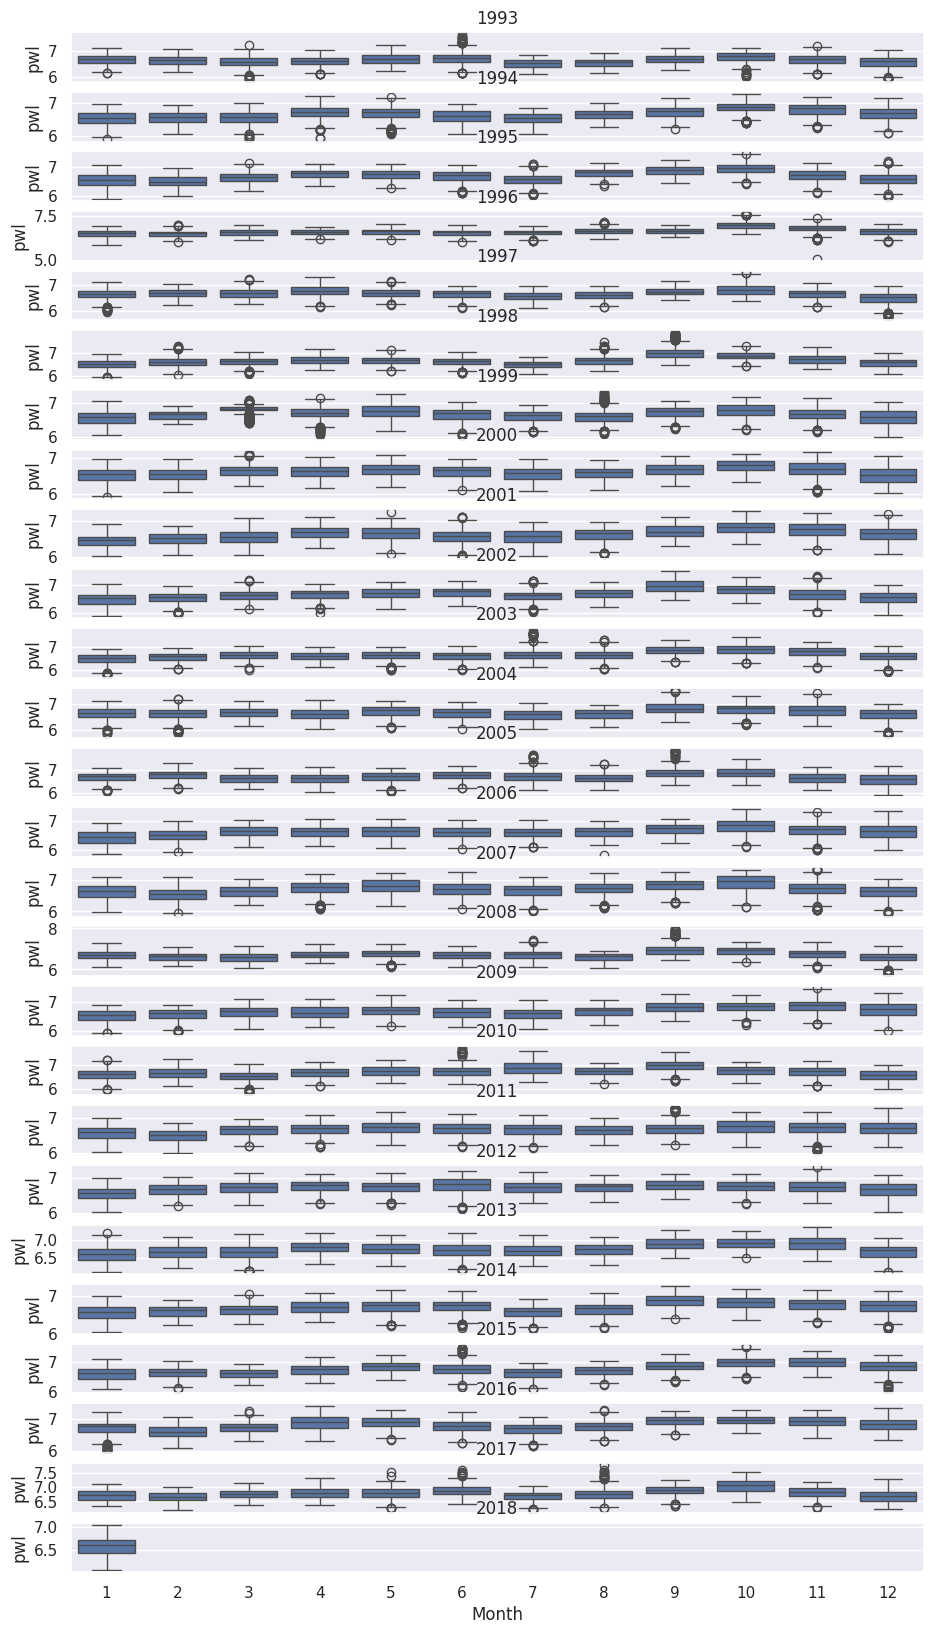

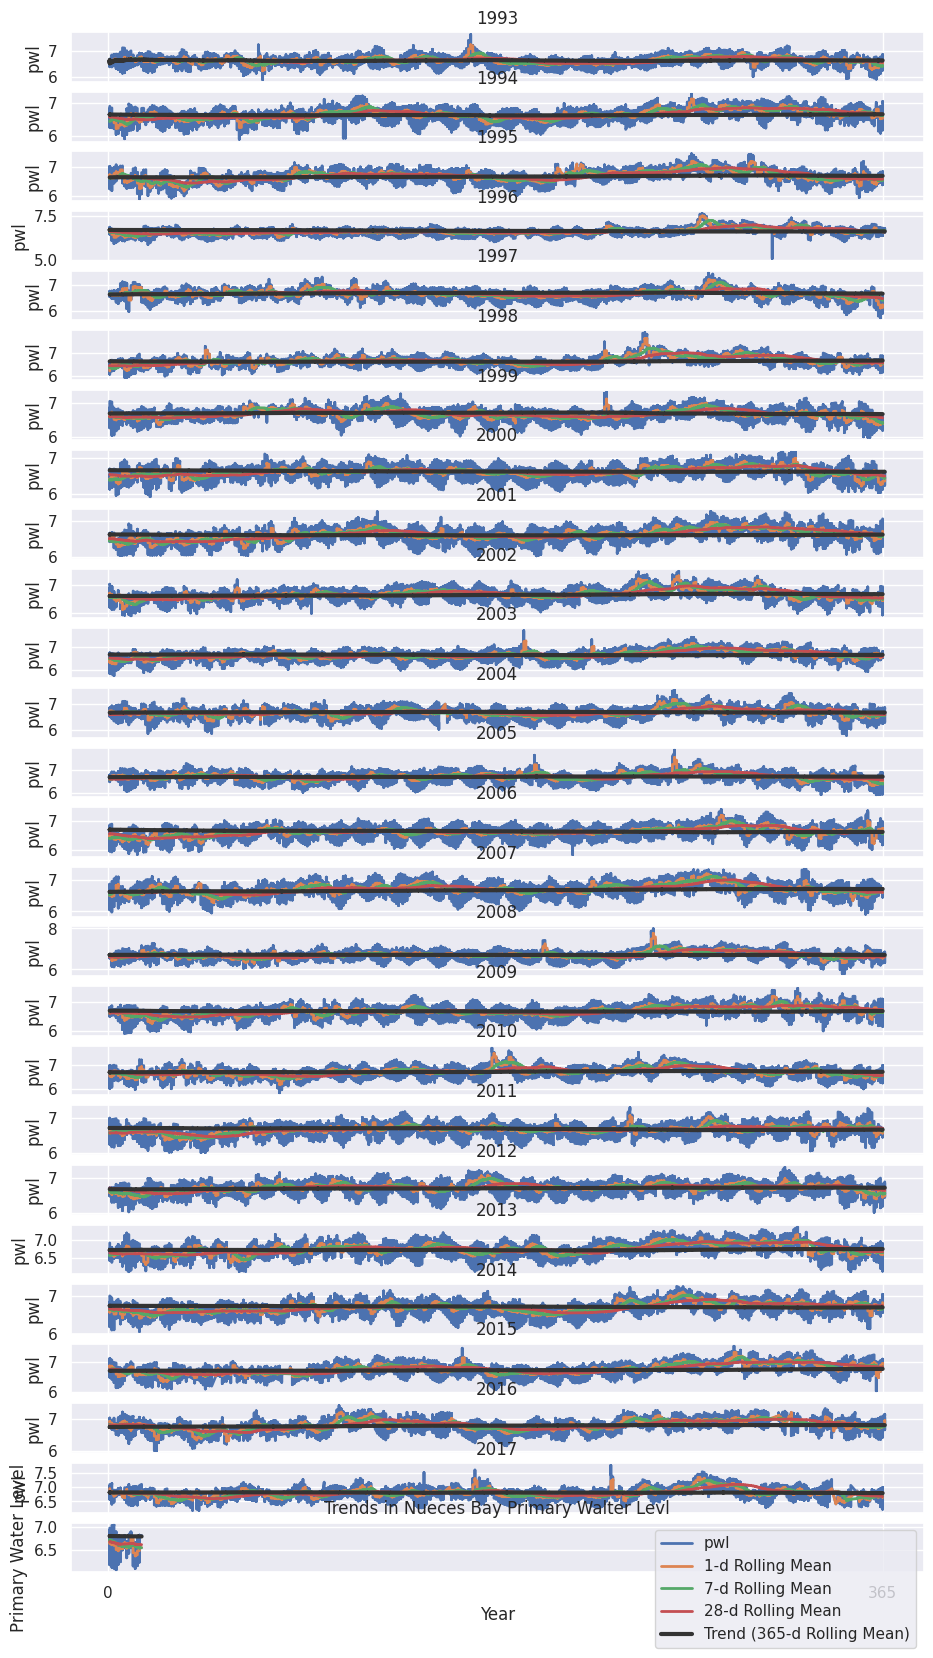

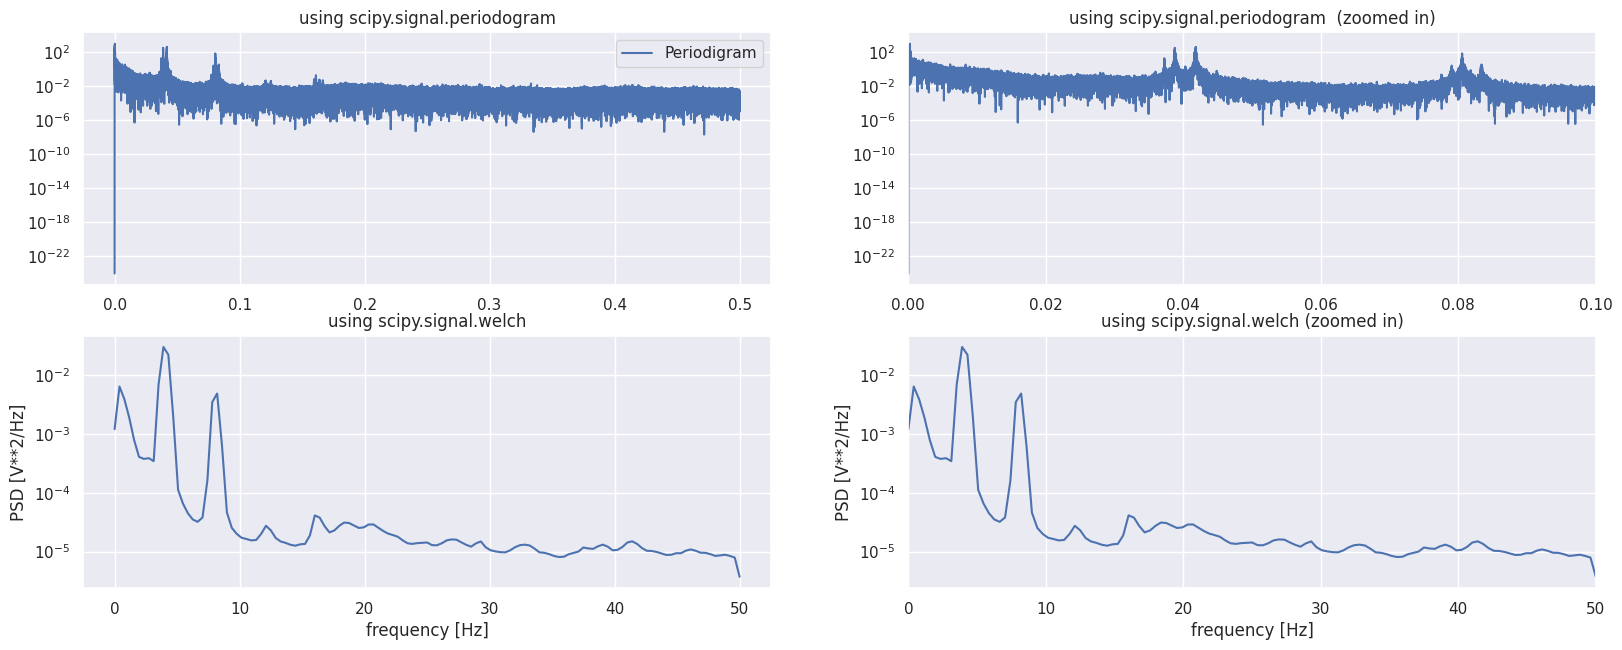

In [ ]:
# Note, this processes two files, one a BHP hourly data set I have, plus Nueces Bay.  You should be able to modify
# to handle the new 6-min BHP dataset, just need to fix the column names, and maybe process the other columns.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import datetime
from scipy import stats
from scipy import signal
# from spectrum import *

# from pylab import plot

print('Hi', flush=True)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]
def processDigitalLibraryTideFile(url, series, removeOutliers=False, removeMising=False):
    print('processing ', url, flush=True)
    df = pd.read_csv(url)

    if removeMising:
        print('removing missing values', flush=True)
        df = df.dropna()

    if (removeOutliers):
        print('removing outliers', flush=True)
        #  df = df[(np.abs(stats.zscore(df)) < 3).all(axis=1)] # If you want to check all columns
        df = df.iloc[np.abs(stats.zscore(df[series]))<3]
#        df.iloc[np.abs(stats.zscore(df["185-pwl"]))<3] = np.NaN

    # Let's rename
    df['#date+time'] = pd.to_datetime(df['#date+time'], errors='coerce')
    df = df.rename(columns={'#date+time':'time', series:'pwl'})
    df = df.set_index('time')

    return df.copy()



def plot_yearly_monthly(df,series):
    sns.set(rc={'figure.figsize':(11, 4)})
    sns.boxplot(data=df, x='Year', y=series)
    plt.show()
    sns.boxplot(data=df, x='Month', y=series)
    plt.show()
    sns.boxplot(data=df, y=series)
    plt.show()
    sns.boxenplot(data=df, x='Year', y=series)
    plt.show()
    sns.boxenplot(data=df, x='Month', y=series)
    plt.show()
    sns.boxenplot(data=df, y='pwl')
    plt.show()
    sns.violinplot(data=df, x='Month', y=series)
    plt.show()
    sns.violinplot(data=df, x='Year', y=series)
    plt.show()
    sns.violinplot(data=df,  y=series)
    plt.show()


def plot_monthly_by_year(df):
    Years = df.Year.unique()
    numYears = len(Years)
    fig, axes = plt.subplots(numYears, 1, figsize=(11, 20), sharex=True)
    for yr, ax in zip(Years, axes):
        sns.boxplot(data=df.query('Year == '+str(yr)), x='Month', y='pwl', ax=ax)
        ax.set_ylabel('pwl')
        ax.set_xlabel('Month')
        ax.set_title(yr)
        # Remove the automatic x-axis label from all but the bottom subplot
        if ax != axes[-1]:
            ax.set_xlabel('')


def plot_smoothing_trends(df):
    Years = df.Year.unique()
    numYears = len(Years)
    fig, axes = plt.subplots(numYears, 1, figsize=(11, 20), sharex=True)
    for yr, ax in zip(Years, axes):
        rows = df.query('Year == '+str(yr)).index
        #rows = NuecesBaydf.query('Year == '+str(yr)).index  -NuecesBaydf.query('Year == '+str(yr)).index[0]
        yearrange = df.query('Year == '+str(yr))['DOY']
       # NuecesBaydf.query('Year == '+str(yr)).index  -pd.Timestamp('2010-01-01', tz="UTC")

    #     sns.boxplot(data=NuecesBaydf.loc[range], x='Month', y='pwl', ax=ax)
        ax.set_ylabel('pwl')
        ax.set_xlabel('Month')
        ax.set_title(yr)

        ax.plot(yearrange, df.loc[rows]['pwl'], linewidth=2, label='pwl')
        ax.plot(yearrange, df.loc[rows]['pwl 1d'], linewidth=2, label='1-d Rolling Mean')
        ax.plot(yearrange, df.loc[rows]['pwl 7d'], linewidth=2, label='7-d Rolling Mean')
        ax.plot(yearrange, df.loc[rows]['pwl 28d'], linewidth=2, label='28-d Rolling Mean')
        ax.plot(yearrange, df.loc[rows]['pwl 365d'], color='0.2', linewidth=3,label='Trend (365-d Rolling Mean)')
        ax.xaxis.set_major_locator(mdates.YearLocator())


        # Remove the automatic x-axis label from all but the bottom subplot
        if ax != axes[-1]:
            ax.set_xlabel('')

    # Set x-ticks to yearly interval and add legend and labels

    ax.legend()
    ax.set_xlabel('Year')
    ax.set_ylabel('Primary Water Level')
    ax.set_title('Trends in Nueces Bay Primary Walter Levl');


def plot_periodogram(df):
    fig = plt.figure()
    x = df['pwl']
    fs = 1
    f, Pxx_den = signal.periodogram(x, fs)

    fig.subplots_adjust(right=1.5)
    fig.subplots_adjust(top=1.5)
    ax1 = fig.add_subplot(221)
    plt.title('using scipy.signal.periodogram')
    plt.semilogy(f, Pxx_den)
    ax2 = fig.add_subplot(222)
    ax2.set_xlim(0, .1)
    plt.title('using scipy.signal.periodogram  (zoomed in)')
    plt.semilogy(f, Pxx_den)


    ax3 = fig.add_subplot(223)

    f, Pxx_den = signal.welch(x, fs=100)
    plt.semilogy(f, Pxx_den)
    plt.title('using scipy.signal.welch')
    plt.xlabel('frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')

    ax4 = fig.add_subplot(224)

    plt.title('using scipy.signal.welch (zoomed in)')
    plt.semilogy(f, Pxx_den)
    ax1.legend(['Periodigram']);


    # plt.ylim([0.5e-3, 1])

    ax4.set_xlim(0, 50)
    plt.xlabel('frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.show()

def processNuecesBay():
    PWLdf = processDigitalLibraryTideFile("NuecesBay_RawDataOnly.csv", series='185-pwl', removeOutliers=True, removeMising=True)
    # now that we have a datetime column, let's make that the index

    PWLdf.asfreq('6min',method='ffill')  # Let's fill holes.

    # Let's get every 6min and fill it if we need it.  But same size as before, so we ar good.
    #NuecesBaydf.asfreq('6min',method='ffill')
    # NuecesBaydf.plot()

    # Add columns with year, month, and weekday name
    PWLdf['Year'] = PWLdf.index.year
    PWLdf['Month'] = PWLdf.index.month
    PWLdf['Weekday'] = PWLdf.index.weekday
    PWLdf['DOY'] = PWLdf.index.dayofyear
    # Display a random sampling of 5 rows
    # NuecesBaydf.sample(5, random_state=0)


    # Use seaborn style defaults and set the default figure size
    sns.set(rc={'figure.figsize':(11, 4)})
    PWLdf['pwl'].plot(linewidth=0.5);
    plt.show()
    PWLdf.query('Year == 2010 and Month == 2')['pwl'].plot(linewidth=0.5);
    plt.show()
    PWLdf.loc[PWLdf['Year']==2018, 'pwl'].plot(linewidth=0.5);
    plt.show()
    sns.boxplot(data=PWLdf, x='Year', y='pwl')

    plot_yearly_monthly(PWLdf, 'pwl')
    plot_monthly_by_year(PWLdf)

    # Do some smoothing
    PWLdf['pwl 1d'] = PWLdf['pwl'].rolling('1d').mean()
    PWLdf['pwl 7d'] = PWLdf['pwl'].rolling('7d').mean()
    PWLdf['pwl 28d'] = PWLdf['pwl'].rolling('28d').mean()
    PWLdf['pwl 365d'] = PWLdf['pwl'].rolling('365d').mean()

    plot_smoothing_trends(PWLdf)
    plot_periodogram(PWLdf)
    return PWLdf


# PWLdf = processDigitalLibraryTideFile("NuecesBay_RawDataOnly.csv", removeOutliers=True, removeMising=True)
# # now that we have a datetime column, let's make that the index
# #PWLdf.asfreq('6min',method='ffill')  # Let's fill holes.
# plot_yearly_monthly(PWLdf, 'pwl')
# plot_monthly_by_year(PWLdf)
# plot_smoothing_trends(PWLdf)
# plot_periodogram(PWLdf)

def process_BHP():
    PWLdf = processDigitalLibraryTideFile("BHP9317data.csv", series='pwl',removeOutliers=False, removeMising=True)
    # now that we have a datetime column, let's make that the index
    #PWLdf.asfreq('6min',method='ffill')  # Let's fill holes.
    # Add columns with year, month, and weekday name

    PWLdf['Year'] = PWLdf.index.year
    PWLdf['Month'] = PWLdf.index.month
    PWLdf['Weekday'] = PWLdf.index.weekday
    PWLdf['DOY'] = PWLdf.index.dayofyear
    plot_yearly_monthly(PWLdf, 'pwl')
    plot_monthly_by_year(PWLdf)
    PWLdf['pwl 1d'] = PWLdf['pwl'].rolling('1d').mean()
    PWLdf['pwl 7d'] = PWLdf['pwl'].rolling('7d').mean()
    PWLdf['pwl 28d'] = PWLdf['pwl'].rolling('28d').mean()
    PWLdf['pwl 365d'] = PWLdf['pwl'].rolling('365d').mean()
    plot_smoothing_trends(PWLdf)
    plot_periodogram(PWLdf)
    return PWLdf

BHPdf = process_BHP()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scalar = MinMaxScaler(feature_range=(0, 1))
BHP9317data = pd.read_csv('BobHallPierOct2007Sep202 - Cleaned.csv')
# Assuming 'pwl' is the column you want to scale, adjust accordingly
scaled = scalar.fit_transform(BHP9317data[['014-surge']]) # Scale the 'pwl' column

In [ ]:
import numpy as np

def create_sequences(data, past_steps, future_steps):
    X, y = [], []
    for i in range(len(data) - past_steps - future_steps):
        X.append(data[i:i + past_steps, :])
        y.append(data[i + past_steps:i + past_steps + future_steps])
    return np.array(X), np.array(y)

#define past and future steps (using previous 48 hrs to predict next 24)
past_steps = 72
future_steps = 24
X, y = create_sequences(scaled, past_steps, future_steps)

In [ ]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

#first and second layer
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

#output layer for future steps
model.add(Dense(units=future_steps))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 72, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 72, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24)                  │           1,560 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,480 (201.09 KB)

 Trainable params: 51,480 (201.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

Epoch 1/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0297 - val_loss: 0.0226
Epoch 2/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - loss: 0.0036 - val_loss: 0.0234
Epoch 3/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0026 - val_loss: 0.0225
Epoch 4/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 0.0024 - val_loss: 0.0230
Epoch 5/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - loss: 0.0022 - val_loss: 0.0228
Epoch 6/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 0.0021 - val_loss: 0.0232
Epoch 7/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0023 - val_loss: 0.0212
Epoch 8/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0022 - val_loss: 0.0219
Epoch 9/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0024 - val_loss: 0.0215
Epoch 10/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0022 - val_loss: 0.0223
Epoch 11/50
2492/2492 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0022 - val_loss: 0.0222
Epoch 12

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np

predicted = model.predict(X_test)

scaler = MinMaxScaler()
scaler.fit(scaled)
predited = scaler.inverse_transform(predicted)
print("Shape of predicted:", predicted.shape)
print("Shape of y_test:", y_test.shape)
y_test_2d = y_test.reshape(y_test.shape[0] * y_test.shape[1], y_test.shape[2])

# Apply the inverse transform
predicted_inverse = scaler.inverse_transform(predicted)
y_test_inverse = scaler.inverse_transform(y_test_2d)

predicted_inverse_reshaped = predicted_inverse.reshape(predicted.shape)
y_test_inverse_reshaped = y_test_inverse.reshape(y_test.shape)

y_test_reshaped = y_test.reshape(y_test.shape[0], y_test.shape[1])

y_test_reshaped = np.nan_to_num(y_test_reshaped)

rmse = np.sqrt(mean_squared_error(y_test_reshaped, predicted))
print("Root Mean Squared Error (RMSE):", rmse)

534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Shape of predicted: (17082, 24)
Shape of y_test: (17082, 24, 1)
Root Mean Squared Error (RMSE): 0.07077787039995985


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict on the test data
predicted = model.predict(X_test)

# Rescale the data back to the original range
scaler = MinMaxScaler()
scaler.fit(scaled)  # Ensure the scaler is fitted on the original scaled data

# Reshape y_test for inverse transformation
y_test_2d = y_test.reshape(-1, y_test.shape[2])  # Flatten to 2D for inverse scaling

# Apply the inverse transform
predicted_inverse = scaler.inverse_transform(predicted)
y_test_inverse = scaler.inverse_transform(y_test_2d)

# Reshape back to the original shape for comparison
predicted_inverse_reshaped = predicted_inverse.reshape(predicted.shape)
y_test_inverse_reshaped = y_test_inverse.reshape(y_test.shape)

# Handle NaN values in y_test_inverse_reshaped
y_test_inverse_reshaped = np.nan_to_num(y_test_inverse_reshaped)

# Ensure the shapes match before calculating RMSE
predicted_reshaped = predicted_inverse_reshaped.reshape(y_test_inverse_reshaped.shape)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_inverse_reshaped.flatten(), predicted_reshaped.flatten()))
print("Root Mean Squared Error (RMSE):", rmse)


534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Root Mean Squared Error (RMSE): 0.8097441592283945


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# CF 15
within_15_percent = np.abs((predicted_reshaped - y_test_inverse_reshaped) / y_test_inverse_reshaped) <= 0.15
cf_15 = np.sum(within_15_percent) / y_test_inverse_reshaped.size * 100
print("CF 15 (%):", cf_15)

# MSE
mse = mean_squared_error(y_test_inverse_reshaped.flatten(), predicted_reshaped.flatten())
print("Mean Squared Error (MSE):", mse)

# MAU
mau = np.mean(np.abs(y_test_inverse_reshaped.flatten() - predicted_reshaped.flatten()))
print("Mean Absolute Uncertainty (MAU):", mau)

# R²
r2 = r2_score(y_test_inverse_reshaped.flatten(), predicted_reshaped.flatten())
print("R² (Coefficient of Determination):", r2)

CF 15 (%): 0.029270577215782696
Mean Squared Error (MSE): 0.6556856034044994
Mean Absolute Uncertainty (MAU): 0.7951295665241863
R² (Coefficient of Determination): -33.53685416982286


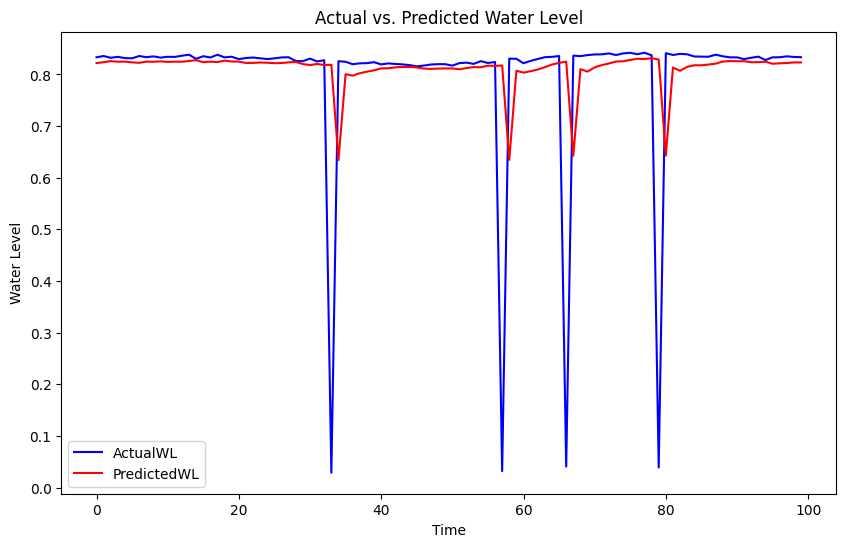

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test[:100, 0], label='ActualWL', color='blue')
plt.plot(predicted[:100, 0], label='PredictedWL', color='red')
plt.xlabel('Time')
plt.ylabel('Water Level')
plt.title('Actual vs. Predicted Water Level')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
